# New Section

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('cardio_train.csv', sep=';')

# Convert age from days to years
df['age'] = (df['age'] / 365.25).apply(np.floor).astype(int)

# Inspect structure
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB
None
                 id           age        gender        height        weight  \
count  70000.000000  70000.000000  70000.000000  70000.000000  70000.000000   
mean   49972.419900     52.803257      1.349571

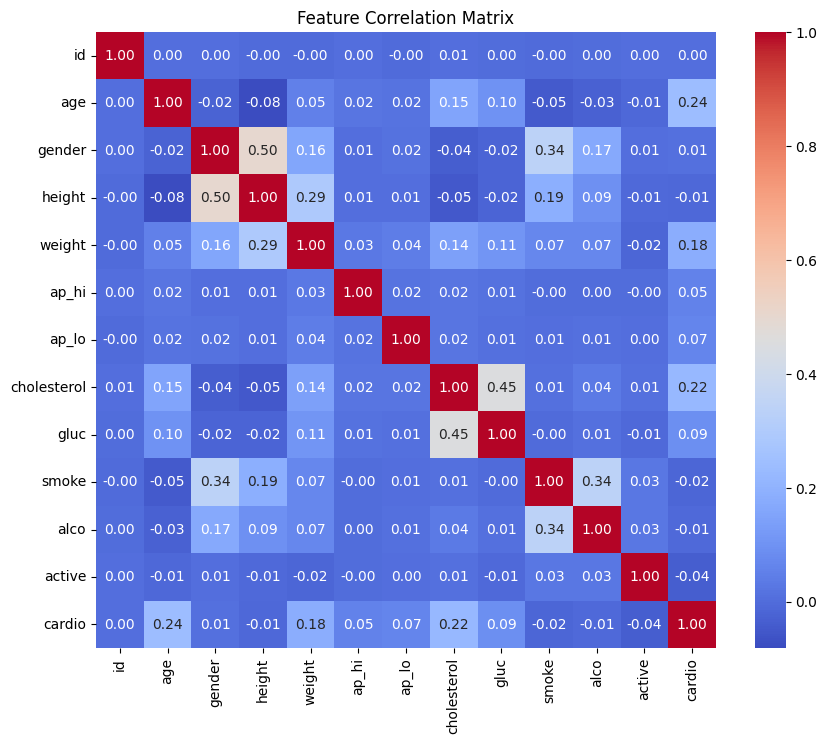

In [4]:
# Correlation Heatmap
plt.figure(figsize=(10,8))
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Matrix')
plt.show()

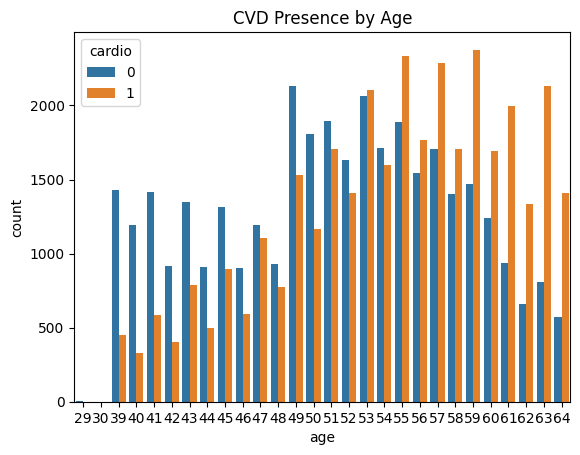

In [7]:
# Visualization of CVD presence by Age
sns.countplot(x='age', hue='cardio', data=df)
plt.title('CVD Presence by Age')
plt.show()

In [10]:
import numpy as np

# Define numerical features for outlier check
numeric_features = ['height', 'weight', 'ap_hi', 'ap_lo']

# Calculate IQR
Q1 = df[numeric_features].quantile(0.25)
Q3 = df[numeric_features].quantile(0.75)
IQR = Q3 - Q1

# Define bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Treatment: Replace outliers with median to avoid losing 70,000 rows of data
for feature in numeric_features:
    median_val = df[feature].median()
    df[feature] = np.where((df[feature] < lower_bound[feature]) |
                           (df[feature] > upper_bound[feature]),
                           median_val, df[feature])

In [11]:
from scipy.stats import chi2_contingency, ttest_ind

# Chi-Square Test for Cholesterol
contingency = pd.crosstab(df['cholesterol'], df['cardio'])
stat, p, dof, expected = chi2_contingency(contingency)
print(f"Chi-Square P-value for Cholesterol: {p}")

# T-Test for Age
diseased = df[df['cardio'] == 1]['age']
healthy = df[df['cardio'] == 0]['age']
t_stat, p_val = ttest_ind(diseased, healthy)
print(f"T-test P-value for Age: {p_val}")

Chi-Square P-value for Cholesterol: 0.0
T-test P-value for Age: 0.0


In [16]:
# Create Body Mass Index (BMI)
# Formula: BMI = weight(kg) / (height(m)^2)
df['bmi'] = df['weight'] / ((df['height'] / 100) ** 2)

# Create Pulse Pressure (Difference between systolic and diastolic)
# A high pulse pressure can be a strong indicator of heart issues
df['pulse_pressure'] = df['ap_hi'] - df['ap_lo']
df['age_group'] = pd.cut(df['age'], bins=[29, 39, 49, 59, 64],
                         labels=['29-39', '40-49', '50-59', '60-64'], right=True)

In [18]:
from imblearn.over_sampling import SMOTE
import pandas as pd

# Define X and y
X = df.drop('cardio', axis=1)
y = df['cardio']

# Drop 'id' column as it's an identifier and not a feature
X = X.drop('id', axis=1)

# Handle potential NaNs in 'age_group' (if age values fell outside defined bins)
# Convert 'age_group' to object type if it's categorical to safely use fillna with mode
if 'age_group' in X.columns and X['age_group'].isnull().any():
    X['age_group'] = X['age_group'].astype(object).fillna(X['age_group'].mode()[0])

# Identify categorical columns for one-hot encoding
# These columns represent categories despite being integer type or object type ('age_group').
categorical_features = ['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'age_group']

# Convert categorical features to one-hot encoded features
# Use pd.get_dummies to convert these columns. drop_first=True helps prevent multicollinearity.
X = pd.get_dummies(X, columns=categorical_features, drop_first=True)

# Apply SMOTE
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

print(f"New class distribution: {y_res.value_counts()}")

New class distribution: cardio
0    35021
1    35021
Name: count, dtype: int64
